we will be building a neural network class that contains the neurons 
so the idea is building a basic fully functional neural network engine that implements the forward/backword pass and the ofc the train loop 

**to start with**, *neural networks* are just a <ins>mathematical expression</ins> just like this one **"e = (a + b) * (c ** d)"** with a much complex expressions that can represent a phenomenon.

where each atom in the expression is a neuron in the network.
So basicly we'll build the network for this expression in this repository 

so what needs to be mentioned here for this repo is that the power of the neural net came from a total of 200 line of code and every single code more than those 200 lines of code are just effiency (a lot of effiency being imoplemented). 

In [29]:
import numpy as np 
import pandas as pd 
import matplotlib as plt 
from graphviz import Digraph
import math as Math
import torch

lets start by the first step which is how to handle our nn inputs that are a punch of long lists of numbers4.

for that we need such a data structure that can facilitate the manipulation of those numbers throughout the network

In [24]:
class value : 
    def __init__(self ,  data , _children = [] , _op = "" , label = ""):
        self.data = data
        self._prev   = set( _children) ## the reason why we're implemeting children as a set not as a list for two main reasons 1. avoid dupolicate when the prent is a result of addition of the same child like b = a + a so [] a list would duplicate the a where the set will avoid the duplication 2. time complexity cuz the set is faster than the list when it comes to searching
        self._op = _op 
        self.label = label
        self._backward = lambda : None
        self.grad = 0 ## the grads are initially seted to zero indocating that at the first pass the weights has no effect on the output 
    def __repr__(self):
        chidlren_str = f"childrens = {self._prev}" if self._prev else "no children"
        return f"value : data = {self.data} {chidlren_str} {self._op}"
    ## so now when we have built our data structure we need to give it some power so we need more than just have the value we need to be able to add different values up 
    def __add__(self , other ):
        other   = other if isinstance(other , value) else value(other)
        out = value(self.data + other.data , (self , other) , "+")
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0  * out.grad
            print(f"b grad = " , other.grad , "x1w1x2w2 grad = " , self.grad)
        out._backward = _backward
        return out
    ## now we have implemented the add (we have gave our engin the power to add values we need more functionalities that will be added as well )
    def __mul__(self , other):
        other   = other if isinstance(other , value) else value(other)
        out = value(self.data * other.data , (self , other) , "*" )
        def _backward():
            self.grad = other.data  * out.grad
            other.grad = self.data  * out.grad
        out._backward = _backward 
        return out
    ##now we need to represent our network as a graph so we need to give keep track of which neurons are children fo the other neurons so we need to add a children attribute to our value class
    ## and since the operation are also a nodes in our graph we need to keep track of them as the member variable _op
    
    def sigmoid(self):
        v = 1 / (1 + Math.exp( - self.data )) # this may seems correct but it's not cuz we need to get the childs for the sigmoid output so we need to perform the operations on the values objects not on the integers, so how we can hendle that is as follows 
        #actually we dont need to impelment every atomic function for the engine all we need is to know the local derivitive of that function. so we can just use the oredefined functions and then return a value object with harcoded childes as the self. 
        out  = value(v , (self , ),  "sigmoid")
        def _backward():
            self.grad = v*(1 - v)* out.grad
            print(f"n.grad=" , self.grad)
        out._backward = _backward
        return  out
    
    
    def backward(self):
        topo =  []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo
        self.grad = 1.0 
        for node in reversed(topo):
            node._backward()

# so now the idea is we need somehow to call the _backward function for each node in the graph so we need to implement a topological sort algorithm to sort the nodes in the graph and then call the _backward function for each node in the sorted order



In [3]:
## the visualization fo the graph network 

def trace(root) : 
    nodes , edges = set() ,set() 
    def build(v) : 
        if  not isinstance(v , value) : 
            print("the v is not a value")
        if v not in nodes :
            nodes.add(v)
            for child in v._prev :
                edges.add((child , v))
                build(child)
    build(root)
    return nodes , edges 
def draw_graph (root):
    dot = Digraph(format = "svg" , graph_attr = {"rankdir" : "LR"}) ## Lr stends for left to right as the mathematical exressions are written
    nodes , edges = trace(root)
    for n in nodes :
        uid = str(id(n))
        dot.node(name = uid , label = "{%s | data = %.4f | grad = %.4f}"%(n.label , n.data , n.grad) , shape = "record")
        if n._op : 
            dot.node(name = uid  + n._op , label = n._op )
            dot.edge(uid + n._op , uid)
    for n1 , n2 in edges : 
        dot.edge(str(id(n1)) ,str(id(n2)) + n2._op )
    return dot

## introducing neurons

basicly neuron is a function that takes inputs and squash them to an output that represent a non linear combination of the input (why is that is for another code or repo) the squash function that we will be using is the sigmoid and then in up comming repos we'll get ride of it when we inroduce the mlp architecture

In [15]:
x1 = value(2 , [] , "x1")
x2 = value(2 , [] , "x2")
w1 = value(2 , [] , "w1")
w2 = value(2 , [] , "w2")
b = value(1 , [] , "b")
b.label = "b"
x1w1 = x1 * w1 ; x1w1.label = "x1w1"
x2w2 = x2 * w2 ; x2w2.label = "x2w2"
x1w1x2w2 = x1w1 + x2w2 ;x1w1x2w2.label = "x1w1x2w2" 
n =x1w1x2w2 + b ; n.label = "n"
s = n.sigmoid() ; s.label = "ouput"


In [16]:
s.backward()

n.grad= 0.00012337934976493025
b grad =  0.00012337934976493025 x1w1x2w2 grad =  0.00012337934976493025
b grad =  0.00012337934976493025 x1w1x2w2 grad =  0.00012337934976493025


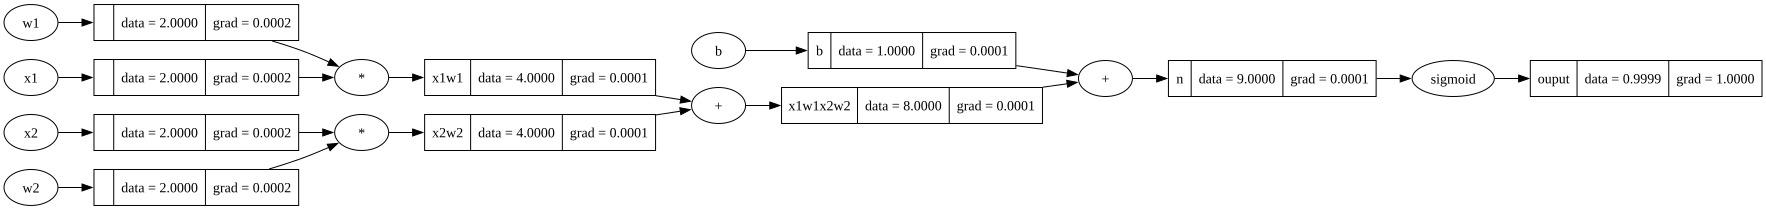

In [17]:
draw_graph(s)

b grad =  0.12337934976493024 x1w1x2w2 grad =  0.12337934976493024
b grad =  0.12337934976493024 x1w1x2w2 grad =  0.12337934976493024


now we've got all the gradient to update the network and run ana optimization step 
the problem is that we must ensure that no gradient is calculated before every thing after it is done 

in other words the backward pass must never be done before the forward pass is totaly done 
how is that :

using something called topological sort. a type of graph. are a lign out of nodes such that the edges always go from left to right

lets implement the topological sort 


now lets introduce the gradient bug 

In [27]:
a = value(-2 , [] , "a")
b = value( 3, [] , "b")
c =  a + b ; c.label = "c"
d =  a * b ; d.label = "d"
e = d * c ; e.label = "e"

e.backward()

b grad =  -8.0 x1w1x2w2 grad =  -3.0


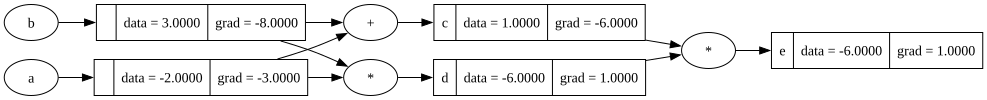

In [28]:
draw_graph(e)

#### now lets get our selfs to the pytorch frame work

In [ ]:
x1 = torch.tensor([2.0]).double() ; x1.requires_grad = True # we need to define the required grad to true cuz torch by defaullt assumes that the leaf nodes does not need gradients , cuz usually the leaf nodes are the input and we dont need gradients for the input and that some sort of efficiency done by torch 
x2 = torch.tensor([0.0]).double() ; x2.requires_grad = True 
w1 = torch.tensor([-3.0]).double() ; w1.requires_grad = True 
w2 = torch.tensor([1.0]).double() ; w2.requires_grad = True 
b = torch.tensor([6.8813]).double() ; b.requires_grad = True 

x1w1 = x1 * w1 
x2w2 = x2 * w2 
x1w1x2w2 = x1w1 + x2w2 
n =x1w1x2w2 + b 
s = torch.sigmoid(n)

print(s.data.item())

s.backward()



0.7070915348949963
